# AICE Associate 초급 불시시험

## 커피 원두 품질등급 예측 (분류)


### 시험 안내

- **총 문항 수** : 14문항 (대문항 기준)
- **시험 시간** : 약 50~60분
- **사용 데이터** : `coffee_quality_data.csv`
- **배점** : 데이터 분석 20점 + 데이터 전처리 30점 + AI 모델링 50점 = 총 100점

### 시나리오

원두 도매업체 B사는 수입하는 원두의 품질이 들쭉날쭉하다는 평가를 받으며 재구매율이 하락하고 있다.
품질관리팀은 그동안 축적된 원두 감별사(cupper)의 평가 데이터를 활용해 **원두품질등급(Pass/Fail)**을
예측하는 인공지능 모델을 도입하여, 등급이 낮은 원두를 사전에 선별하고자 한다.

### 유의사항

- 각 문항의 답안은 반드시 `# 여기에 답안코드를 작성하고 실행하세요`, `# 여기에 답안을 입력하세요` 등이
  표시된 셀(cell)에 입력해야 합니다.
- 제공된 시험문항 셀을 삭제하거나 답안 위치가 아닌 다른 셀에 답안코드를 작성 시 채점되지 않습니다.
- 답안 작성 전에 문항에 제시된 가이드를 확인하세요.
- 문항에 변수명이 제시된 경우 반드시 해당 변수명을 사용하세요.


### 데이터 컬럼 설명 (데이터 파일명: `coffee_quality_data.csv`)

| 컬럼 | 설명 |
|---|---|
| Grade | 원두품질등급 (Pass, Fail) — **예측 대상** |
| C_title | 원두 이름 |
| C_country | 생산국가 |
| C_region_1 | 생산지 세부주소 ① |
| C_region_2 | 생산지 세부주소 ② |
| C_farm | 생산 농장명 |
| C_harvest_year | 수확연도 |
| C_bean_variety | 원두 품종 |
| C_process_type | 가공방식 |
| C_continent | 생산대륙 (0/1로 인코딩) |
| C_price | 가격 (달러/파운드) |
| C_points_region | 생산지 평점 |
| C_points_variety | 품종 평점 |
| C_points_farm | 농장(재배) 평점 |


## <데이터 분석 (20점)>

**1.** scikit-learn은 머신러닝에 널리 사용되는 파이썬 라이브러리입니다.

scikit-learn을 사용할 수 있게 별칭(alias)을 **sk**로 해서 불러오세요.

In [1]:
# (1) 여기에 답안코드를 작성하고 실행하세요
import sklearn as sk

> **해설** : `import ... as ...` 구문으로 라이브러리에 별칭을 지정해 불러올 수 있습니다.
>
> **학습 포인트** : scikit-learn은 관례적으로 `sk`, `sklearn` 등으로 불러오지만, 실제로는 세부 모듈
> (`from sklearn.tree import ...`)을 그때그때 불러와 사용하는 경우가 더 많습니다.
>
> **자주 하는 실수** : `import sklearn as sk` 대신 `import scikit-learn as sk`처럼 패키지명을 그대로
> 적으면 오류가 발생합니다 (설치 패키지명과 import 이름이 다름에 유의).

**2.** AI 모델링을 위해 분석 및 처리할 데이터 파일을 읽어오려고 합니다.

pandas로 데이터 파일을 읽어온 뒤, 데이터프레임 변수명 **data**에 할당하고 첫 4개 행을 출력하세요.

- 데이터프레임 변수명 : `data`
- 데이터 파일명 : `coffee_quality_data.csv`
- csv 파일은 본 문제/답안지와 동일한 경로에 있습니다

In [2]:
# (2) 여기에 답안코드를 작성하고 실행하세요
import pandas as pd
data = pd.read_csv('./coffee_quality_data.csv')
data.head(4)

,Grade,C_title,C_country,C_region_1,C_region_2,C_farm,C_harvest_year,C_bean_variety,C_process_type,C_continent,C_price,C_points_region,C_points_variety,C_points_farm
0,Pass,Bourbon 2022 Farm-4047,Guatemala,Huila,-,Farm-4047,2022,Bourbon,washed,0,3.8,85.7,87.2,80.0
1,Fail,SL28 2022 Garden-2963,Brazil,Yirgacheffe,-,Garden-2963,2022,SL28,honey,0,NaN,83.6,81.6,89.7
2,Pass,Typica 2020 Farm-5682,Guatemala,Kirinyaga,West Ridge,Farm-5682,2020,Typica,washed,0,6.1,81.7,81.3,86.7
3,Pass,SL28 2021 Farm-6965,Kenya,Antigua,East Valley,Farm-6965,2021,SL28,anaerobic,1,5.7,84.4,84.8,79.7


> **해설** : `pd.read_csv()`로 csv 파일을 읽어 DataFrame으로 변환합니다. `head(4)`는 상위 4개 행만
> 미리보기로 확인하는 함수입니다.
>
> **학습 포인트** : 파일 경로는 노트북 파일과 동일한 폴더에 있을 경우 `./파일명.csv` 형태로 지정합니다.
>
> **자주 하는 실수** : 파일명 오타, 확장자 누락, 절대경로/상대경로 혼동으로 인한 `FileNotFoundError`가
> 자주 발생합니다.

In [3]:
# 다음 문항을 풀기 전에 아래 코드를 실행하세요.
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


**3.** 시각화를 통해 가공방식(C_process_type)과 농장 평점(C_points_farm)의 분포를 파악하려 합니다.

- 대상 데이터프레임 : `data`
- 가공방식(C_process_type)의 분포를 보여주는 **countplot** 그래프를 그리세요
- 원두등급(Grade) 별 농장 평점(C_points_farm)의 분포를 보여주는 **histplot** 그래프를 그리세요
- subplots를 활용하여 두 그래프를 가로 방향으로 나란히 그리세요
- 두 그래프의 제목을 각각 `'Process Count'`와 `'Farm Score'`로 설정하세요

아래 코드 셀(cell)에 있는 코드의 빈칸을 채우고 실행하세요.
빈칸에 들어갈 내용은 각 답안 셀(cell)에 입력하세요 (#3-1, #3-2, #3-3)

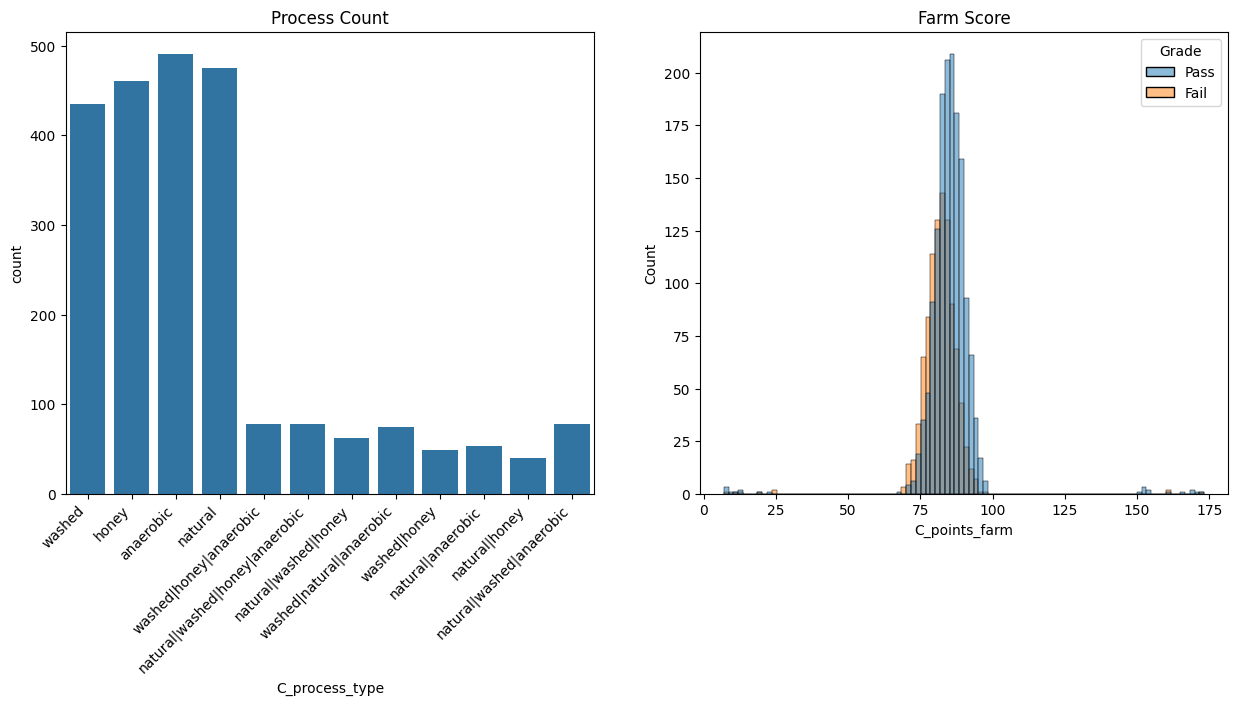

In [4]:
# [정답] (코드 셀) 코드의 빈칸을 채우고 실행하세요
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))
sns.countplot(data=data, x='C_process_type', ax=axes[0])
sns.histplot(data=data, x='C_points_farm', hue='Grade', ax=axes[1])
plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_title('Process Count')
axes[1].set_title('Farm Score')
plt.show()

> **해설** : `plt.subplots(nrows=1, ncols=2)`로 1행 2열의 그래프 영역을 만들고, 각 `ax`에 그래프를
> 하나씩 그립니다. `sns.histplot`의 `hue` 옵션으로 Grade 별 색상을 구분해서 분포 차이를 볼 수 있습니다.
>
> **학습 포인트** : `axes[0]`, `axes[1]`처럼 배열 인덱싱으로 각 subplot에 접근하며, `set_title()`로
> 개별 그래프의 제목을 지정합니다.
>
> **자주 하는 실수** : `ax=axes[0]`처럼 대상 축을 지정하지 않으면 두 그래프가 겹쳐서 그려집니다.

**[정답] (3-1)** _(실행 불필요)_

`subplots`

**[정답] (3-2)** _(실행 불필요)_

`axes`

**[정답] (3-3)** _(실행 불필요)_

`set_title`

**4.** 그래프를 통해 원두품질등급(Grade) 별 농장 평점(C_points_farm) 컬럼의 분포를 확인하려 합니다.

아래 가이드에 따라 boxplot으로 시각화하세요.

- 대상 데이터프레임 : `data`
- seaborn의 boxplot으로 농장 평점(C_points_farm) 컬럼의 분포를 그래프로 그리세요
- X축에는 원두품질등급(Grade)을, Y축에는 농장 평점(C_points_farm)을 표시하세요

<Axes: xlabel='Grade', ylabel='C_points_farm'>

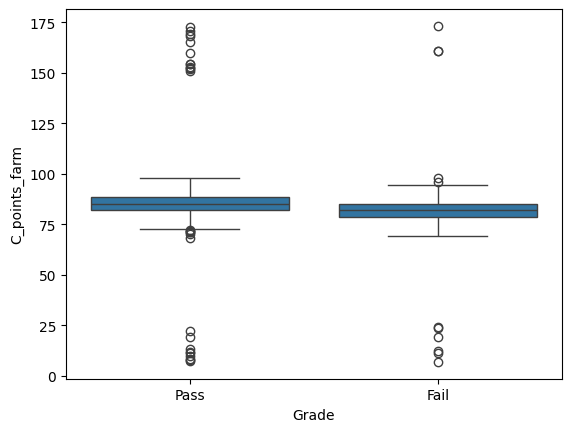

In [5]:
# (4) 여기에 답안코드를 작성하고 실행하세요
sns.boxplot(data=data, x='Grade', y='C_points_farm')

> **해설** : boxplot은 사분위수(Q1, Q3)와 이상치(outlier)를 한눈에 보여줍니다. 박스 밖의 점들이
> 이상치 후보입니다.
>
> **학습 포인트** : 이번 문제에서는 Grade와 무관하게 C_points_farm 전체 분포에서 극단적으로 높거나
> 낮은 값들이 이상치로 관찰됩니다. 이는 다음 문항(5번)의 이상치 처리로 이어집니다.
>
> **자주 하는 실수** : x축과 y축에 넣을 컬럼을 반대로 지정하는 실수가 흔합니다.

## <데이터 전처리 (30점)>

**5.** boxplot으로 확인한 결과, 농장 평점(C_points_farm) 컬럼에서 이상치가 발견되었습니다.
AI모델링할 때 부정적 영향이 없도록 아래 가이드에 따라 이상치를 처리하세요.

- 대상 데이터프레임 : `data`
- 농장 평점이 upperfence 값보다 큰 이상치가 있는 행(row)을 삭제하세요
- 농장 평점이 lowerfence 값보다 작은 이상치가 있는 행(row)을 삭제하세요
- AI모델링에 불필요한 원두 이름(C_title) 컬럼을 삭제하세요
- 전처리를 적용한 데이터프레임은 **data_temp**라는 변수명으로 저장하세요

아래 코드 셀(cell)에 있는 코드의 빈칸을 채우고 실행하세요.
빈칸에 들어갈 내용은 각 답안 셀(cell)에 입력하세요 (#5-1, #5-2)

In [6]:
# [정답] (코드 셀) 코드의 빈칸을 채우고 실행하세요
q1 = data['C_points_farm'].quantile(0.25)
q3 = data['C_points_farm'].quantile(0.75)
iqr = q3 - q1
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

data_temp = data.drop(data[(data['C_points_farm'] > upper_fence) | (data['C_points_farm'] < lower_fence)].index, axis=0)
data_temp = data_temp.drop(columns=['C_title'])
data_temp.reset_index(drop=True, inplace=True)
data_temp.shape

(2457, 13)

> **해설** : IQR(사분위 범위) 방식으로 이상치 경계값(upper_fence, lower_fence)을 계산하고, 해당
> 범위를 벗어나는 행을 `drop(..., axis=0)`으로 삭제합니다. `reset_index`로 인덱스를 재정렬합니다.
>
> **학습 포인트** : `lower_fence = Q1 - 1.5*IQR`, `upper_fence = Q3 + 1.5*IQR` 공식은 boxplot의
> 이상치 판별 기준과 동일합니다.
>
> **자주 하는 실수** : `.drop()`에 `axis`를 지정하지 않거나, 조건식에 괄호를 빠뜨려 연산자 우선순위가
> 꼬이는 경우가 많습니다.

**[정답] (5-1)** _(실행 불필요)_

`drop`

**[정답] (5-2)** _(실행 불필요)_

`index`

**6.** 데이터에 결측치가 있을 경우 AI모델링의 성능이 저하될 수 있습니다.
아래 가이드에 따라 결측치를 확인하고 처리하세요.

**(6-1)** 아래 가이드에 따라 결측치를 처리하고 검증하는데 에러가 나고 있습니다. 코드의 오류를 정정하세요.

- 대상 데이터프레임 : `data_temp`
- 결측치 개수를 확인한 후에 결측치가 있는 행을 모두 삭제하세요
- 전처리가 반영된 데이터프레임은 변수명 **data_na**에 저장하세요
- 결측치가 사라졌는지 확인하세요

**(6-2)** `data_temp`의 결측치 개수는 총 몇 개인가요?

In [7]:
# [정답] (6-1) 여기에 코드의 오류를 정정하고 실행하세요
print('결측치 처리 전\n', data_temp.isnull().sum())
data_na = data_temp.dropna()
print('\n결측치 처리 후\n', data_na.isnull().sum())

결측치 처리 전
 Grade                 0
C_country             0
C_region_1            0
C_region_2            0
C_farm                0
C_harvest_year        0
C_bean_variety        0
C_process_type      123
C_continent           0
C_price             194
C_points_region       0
C_points_variety      0
C_points_farm         0
dtype: int64

결측치 처리 후
 Grade               0
C_country           0
C_region_1          0
C_region_2          0
C_farm              0
C_harvest_year      0
C_bean_variety      0
C_process_type      0
C_continent         0
C_price             0
C_points_region     0
C_points_variety    0
C_points_farm       0
dtype: int64


**[정답] (6-2)** _(실행 불필요)_

`317`

**7.** 원-핫 인코딩(One-Hot Encoding)은 범주형 데이터를 1과 0의 이진형 벡터로 변환하기 위해
사용하는 방법입니다. 아래 가이드에 따라 범주형 데이터를 이진형 벡터로 변환하는 코드를 완성하세요.

**(7-1)** 아래 가이드에 따라 데이터를 처리하는 코드를 작성하고 실행하세요.

- 대상 데이터프레임 : `data_na`
- 가공방식(C_process_type) 컬럼의 값들을 아래 기준에 따라 치환하세요
  - `'washed|honey|anaerobic'`, `'natural|washed|anaerobic'`, `'natural|washed|honey|anaerobic'`, `'washed|natural|anaerobic'` → 4가지 값을 **'anaerobic'** 으로 치환
  - `'washed|honey'` → 1가지 값을 **'washed'** 로 치환
  - `'natural|honey'`, `'natural|anaerobic'`, `'natural|washed|honey'` → 3가지 값을 **'natural'** 로 치환
- 치환 후 가공방식(C_process_type)의 카테고리 별 개수를 출력하세요

아래 코드 셀(cell)에 있는 코드의 빈칸을 채우고 실행하세요.
빈칸에 들어갈 내용은 각 답안 셀(cell)에 입력하세요 (#7-1, #7-2)

In [8]:
# [정답] (코드 셀) 코드의 빈칸을 채우고 실행하세요
data_na.loc[data_na['C_process_type'].isin(['washed|honey|anaerobic', 'natural|washed|anaerobic',
    'natural|washed|honey|anaerobic', 'washed|natural|anaerobic']), ['C_process_type']] = 'anaerobic'
data_na.loc[data_na['C_process_type'].isin(['washed|honey']), ['C_process_type']] = 'washed'
data_na.loc[data_na['C_process_type'].isin(['natural|honey', 'natural|anaerobic', 'natural|washed|honey']), ['C_process_type']] = 'natural'
print(data_na['C_process_type'].value_counts())

C_process_type
anaerobic    736
natural      571
washed       435
honey        409
Name: count, dtype: int64


> **해설** : `.isin([...])`으로 여러 값을 한 번에 조건 검사하고, `.loc[]`으로 해당 행의 값을 다른
> 값으로 치환합니다. `value_counts()`로 치환 후 카테고리별 개수를 확인합니다.
>
> **학습 포인트** : 여러 범주가 혼합된 문자열(`'washed|honey|anaerobic'` 등)을 하나의 대표 범주로
> 정리하는 것은 실제 현업 데이터 전처리에서 매우 흔한 작업입니다.
>
> **자주 하는 실수** : `.isin()` 대신 `==`으로 여러 값을 비교하려 하면 오류가 발생하거나 원하는 결과가
> 나오지 않습니다.

**[정답] (7-1)** _(실행 불필요)_

`isin`

**[정답] (7-2)** _(실행 불필요)_

`value_counts`

**(7-3)** 아래 가이드에 따라 컬럼을 정리하고 원-핫 인코딩하는데 에러가 나고 있습니다. 코드의 오류를 정정하세요.

- 대상 데이터프레임 : `data_na`
- AI모델링에 불필요한 컬럼 4개(`'C_region_1'`, `'C_region_2'`, `'C_farm'`, `'C_bean_variety'`)를 삭제하세요
- 원-핫 인코딩 대상 컬럼은 `'C_country'`, `'C_process_type'` 2개 입니다
- 원-핫인코딩이 반영된 결과를 데이터프레임 변수명 **data_preset**에 저장하세요
- 원-핫인코딩한 결과, 인코딩 대상 컬럼이 변환되었는지 info 함수로 검증하세요

**(7-4)** `data_na`의 가공방식(C_process_type) 중 'washed'의 개수를 작성하세요.

In [9]:
# [정답] (7-3) 여기에 코드의 오류를 정정하고 실행하세요
data_na = data_na.drop(['C_region_1', 'C_region_2', 'C_farm', 'C_bean_variety'], axis=1)
data_preset = pd.get_dummies(data=data_na, columns=['C_country', 'C_process_type'])
data_preset.info()

<class 'pandas.DataFrame'>
Index: 2151 entries, 0 to 2456
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Grade                     2151 non-null   str    
 1   C_harvest_year            2151 non-null   int64  
 2   C_continent               2151 non-null   int64  
 3   C_price                   2151 non-null   float64
 4   C_points_region           2151 non-null   float64
 5   C_points_variety          2151 non-null   float64
 6   C_points_farm             2151 non-null   float64
 7   C_country_Brazil          2151 non-null   bool   
 8   C_country_Colombia        2151 non-null   bool   
 9   C_country_Ethiopia        2151 non-null   bool   
 10  C_country_Guatemala       2151 non-null   bool   
 11  C_country_Kenya           2151 non-null   bool   
 12  C_country_Vietnam         2151 non-null   bool   
 13  C_process_type_anaerobic  2151 non-null   bool   
 14  C_process_type_honey    

> **해설** : 모델링에 불필요한(카디널리티가 너무 높거나 의미가 없는) 컬럼을 제거한 뒤,
> `pd.get_dummies(data=..., columns=[...])`로 원-핫 인코딩을 수행합니다.
>
> **학습 포인트** : `pd.get_dummies()`는 `data`와 `columns`를 키워드 인자로 명확히 지정해야 합니다.
> 위치 인자로 잘못 전달하면 대상 컬럼이 아닌 다른 인자로 해석되어 오류가 발생합니다.
>
> **자주 하는 실수** : `.drop()`에서 `axis=1`을 빠뜨리면 행 삭제로 해석되어 오류가 발생합니다.

**[정답] (7-4)** _(실행 불필요)_

`435`

**8.** 모델링 후에 모델의 성능을 평가할 수 있도록 훈련과 검증 각각에 사용할 데이터셋을 분리하려고 합니다.

원두품질등급(Grade) 컬럼을 레이블값 y로, 나머지 컬럼을 피처값 X로 할당한 후 훈련데이터셋과
검증데이터셋으로 분리하세요.

- 대상 데이터프레임 : `data_preset`
- 훈련데이터셋 레이블 : `y_train`, 훈련데이터셋 피처 : `X_train`
- 검증데이터셋 레이블 : `y_valid`, 검증데이터셋 피처 : `X_valid`
- 훈련데이터셋과 검증데이터셋 비율은 70:30으로 설정하세요
- 훈련데이터셋과 검증데이터셋의 원두등급 비율을 동일하게 하는 옵션을 설정하세요
- 난수 시드는 7로 설정하세요
- scikit-learn의 `train_test_split` 함수를 활용하세요

In [10]:
# (8) 여기에 답안코드를 작성하고 실행하세요
from sklearn.model_selection import train_test_split

X = data_preset.drop('Grade', axis=1)
y = data_preset['Grade']
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.3, random_state=7, stratify=y)

> **해설** : 예측 대상(Grade)을 y로, 나머지를 X로 분리한 뒤 `train_test_split()`으로 훈련/검증
> 데이터를 나눕니다. `stratify=y`를 지정하면 Pass/Fail 비율이 훈련·검증 세트에서 동일하게 유지됩니다.
>
> **학습 포인트** : `test_size=0.3`은 전체의 30%를 검증 데이터로 사용한다는 의미이며, `random_state`를
> 고정하면 항상 동일한 방식으로 데이터가 분리됩니다.
>
> **자주 하는 실수** : `stratify` 옵션을 빠뜨리면 훈련/검증 데이터의 클래스 비율이 달라질 수 있습니다.

**9.** 스케일링을 통해 데이터 이상치의 영향도를 낮추려고 합니다.

**(9-1)** 아래 가이드에 따라 스케일링 처리하는데 에러가 나고 있습니다. 코드의 오류를 정정하세요.

- sklearn.preprocessing에서 StandardScaler 함수를 import하세요
- StandardScaler 함수를 `ss` 변수에 지정하세요
- 훈련데이터에 대해 StandardScaler를 학습시키고 변환을 적용하세요
- 검증데이터에 학습된 스케일링 기준을 그대로 적용하세요
- 스케일링된 검증데이터의 가장 큰 값을 찾고, 이를 반올림하세요

**(9-2)** StandardScaler 적용 후 검증데이터의 최댓값을 반올림한 결과는 무엇입니까?

In [11]:
# [정답] (9-1) 여기에 코드의 오류를 정정하고 실행하세요
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
X_train = ss.fit_transform(X_train)
X_valid = ss.transform(X_valid)
round(np.max(X_valid))

3

> **해설** : 스케일러는 반드시 훈련 데이터에만 `fit`(학습)하고, 검증 데이터에는 그 기준으로
> `transform`만 적용해야 합니다.
>
> **학습 포인트** : 검증 데이터에 다시 `fit`을 하면 검증 데이터 고유의 통계치가 스케일링에 반영되어
> 데이터 누수(data leakage)가 발생합니다. 실전에서 반드시 지켜야 하는 원칙입니다.
>
> **자주 하는 실수** : `ss.fit_transform(X_valid)`처럼 검증 데이터에도 fit을 다시 호출하는 실수가
> 매우 흔합니다.

**[정답] (9-2)** _(실행 불필요)_

`3`

## <AI 모델링 (50점)>

**10.** 원두품질등급(Grade)을 예측하는 머신러닝 모델을 만들려고 합니다.

DecisionTree와 RandomForest는 여러 규칙을 순차적으로 적용하면서 독립변수 공간을 분할하는 모형으로,
분류와 회귀 분석에 모두 사용될 수 있습니다.

**(10-1)** DecisionTree 모델의 하이퍼파라미터를 아래와 같이 구성하고, 변수에 저장하세요.

- Cross Validation 방법론 중 GridSearchCV를 사용하여 총 5회의 Cross Validation 수행
- 트리의 최대 깊이 후보 : `[3, 5, 7]`
- 노드를 분할하기 위한 최소한의 샘플 데이터수(min_samples_split) 후보 : `[2, 5, 10]`
- GridSearchCV의 scoring 파라미터는 `'accuracy'`, n_jobs 파라미터는 `-1` 로 설정
- DecisionTree 모델의 난수 시드 : 7
- Decision Tree 모델을 **gs_dt** 변수에 저장하세요
- 앞서 분리한 훈련데이터셋으로 fit 함수를 사용해 학습시키세요

**(10-2)** RandomForest 모델의 하이퍼파라미터를 아래와 같이 설정하고, 변수에 저장하세요.

- Cross Validation 방법론 중 GridSearchCV를 사용하여 총 5회의 Cross Validation 수행
- 분류기 개수 후보 : `[100, 200, 300]`
- 트리의 최대 깊이 후보 : `[5, 10, 15]`
- 노드를 분할하기 위한 최소한의 샘플 데이터수(min_samples_split) 후보 : `[2, 5, 10]`
- GridSearchCV의 scoring 파라미터는 `'accuracy'`, n_jobs 파라미터는 `-1` 로 설정
- RandomForest 모델의 난수 시드 : 7
- Random Forest 모델을 **gs_rf** 변수에 저장하세요
- 앞서 분리한 훈련데이터셋으로 fit 함수를 사용해 학습시키세요

**(10-3)** Grid Search를 통해 찾아낸 RandomForest의 최적화된 분류기 개수는 몇 개 인가요?

In [12]:
# (10-1) 여기에 답안코드를 작성하고 실행하세요
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

dt = DecisionTreeClassifier(random_state=7)
param_grid_dt = {
    "max_depth": [3, 5, 7],
    "min_samples_split": [2, 5, 10]
}
gs_dt = GridSearchCV(estimator=dt, param_grid=param_grid_dt, cv=5, scoring='accuracy', n_jobs=-1)
gs_dt.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...andom_state=7)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displaye

> **해설** : `GridSearchCV`는 지정한 하이퍼파라미터 후보들의 모든 조합에 대해 교차검증(Cross
> Validation)을 수행하고, 가장 성능이 좋은 조합을 자동으로 찾아줍니다.
>
> **학습 포인트** : `cv=5`는 데이터를 5등분하여 교차검증한다는 의미이며, `n_jobs=-1`은 가능한 모든
> CPU 코어를 사용해 병렬로 연산해 속도를 높입니다.
>
> **자주 하는 실수** : `param_grid`의 키(key) 이름은 모델의 실제 파라미터 이름과 정확히 일치해야
> 합니다 (오타 시 오류 발생).

In [13]:
# (10-2) 여기에 답안코드를 작성하고 실행하세요
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=7)
param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 15],
    "min_samples_split": [2, 5, 10]
}
gs_rf = GridSearchCV(estimator=rf, param_grid=param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)
gs_rf.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...andom_state=7)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed

> **해설** : RandomForest는 여러 개의 DecisionTree를 앙상블(결합)하여 예측 성능과 안정성을 높인
> 모델입니다. `n_estimators`는 트리의 개수를 의미합니다.
>
> **학습 포인트** : `gs_rf.best_params_`로 GridSearch가 찾은 최적 하이퍼파라미터 조합을 확인할 수
> 있습니다.
>
> **자주 하는 실수** : 후보 값이 많을수록 학습 시간이 크게 늘어나므로, 실습 환경에서는 후보 개수를
> 적절히 조절하는 것이 중요합니다.

**[정답] (10-3)** _(실행 불필요)_

`100`

**11.** 모델의 해석력과 개선 방향을 이해하기 위해 RandomForest 모델의 변수중요도를 파악하려고 합니다.

**(11-1)** 아래 가이드에 따라 모델의 변수중요도를 파악하는데 에러가 나고 있습니다. 코드의 오류를 정정하세요.

- Grid Search를 통해 찾은 최적화된 파라미터가 적용된 gs_rf의 best_estimator를 사용하세요
- 변수중요도 점수와 변수 이름을 매핑하여 DataFrame을 만드세요
- 변수중요도 점수를 기준으로 내림차순 정렬하고 Top 10개만 선정하세요
- 변수중요도 점수를 막대 그래프로 시각화하세요

**(11-2)** 출력된 그래프에서 가장 높은 중요도를 보이는 변수명을 쓰세요.

<Axes: xlabel='importance', ylabel='feature'>

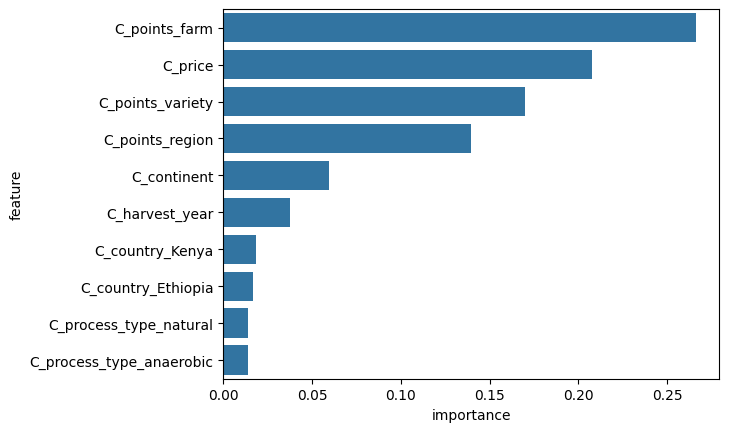

In [14]:
# [정답] (11-1) 여기에 코드의 오류를 정정하고 실행하세요
fi = pd.DataFrame({'feature': X.columns, 'importance': gs_rf.best_estimator_.feature_importances_})
fi = fi.sort_values('importance', ascending=False)[:10]
sns.barplot(x='importance', y='feature', data=fi)

> **해설** : `feature_importances_`는 RandomForest 모델이 예측할 때 각 변수를 얼마나 중요하게
> 사용했는지를 0~1 사이의 값으로 나타냅니다.
>
> **학습 포인트** : `sort_values()`로 중요도가 높은 순서대로 정렬하고, `barplot`으로 시각화하면 어떤
> 변수가 모델 예측에 가장 큰 영향을 미치는지 직관적으로 파악할 수 있습니다.
>
> **자주 하는 실수** : 속성 이름은 `feature_importances_`이며 `importances_`나 `importances`가
> 아닙니다. 정렬 함수도 `sort_values()`이지 `sort_index()`가 아닙니다(둘의 용도가 다름).

**[정답] (11-2)** _(실행 불필요)_

`C_points_farm`

**12.** 앞서 학습시킨 DecisionTree와 RandomForest 모델의 성능을 평가하려고 합니다.

**(12-1)** 아래 가이드에 따라 각 모델의 Accuracy를 산출하려는데 에러가 나고 있습니다. 코드의 오류를 정정하세요.

- Grid Search를 통해 찾은 최적화된 파라미터가 적용된 gs_dt와 gs_rf의 best_estimator를 사용하세요
- 성능 평가는 검증데이터셋을 활용하세요
- 앞서 만든 DecisionTree 모델로 y값을 예측하고, 그 결과를 `y_pred_dt` 변수에 저장하세요
- 검증 정답(y_valid)과 예측값(y_pred_dt)의 Accuracy를 구하고 `dt_acc` 변수에 저장하세요
- 앞서 만든 RandomForest 모델로 y값을 예측하고, 그 결과를 `y_pred_rf`에 저장하세요
- 검증 정답(y_valid)과 예측값(y_pred_rf)의 Accuracy를 구하고 `rf_acc` 변수에 저장하세요
- 2개 모델의 Accuracy값을 출력하세요

**(12-2)** 두 모델의 Accuracy 결과를 비교했을 때, 성능이 더 우수한 모델은 무엇인가요?

In [15]:
# [정답] (12-1) 아래 코드의 오류를 정정하고 실행하세요
y_pred_dt = gs_dt.best_estimator_.predict(X_valid)
y_pred_rf = gs_rf.best_estimator_.predict(X_valid)

from sklearn.metrics import accuracy_score

dt_acc = accuracy_score(y_valid, y_pred_dt)
rf_acc = accuracy_score(y_valid, y_pred_rf)
print(dt_acc, rf_acc)

0.6981424148606811 0.7368421052631579


> **해설** : `best_estimator_`는 GridSearch가 찾은 최적 파라미터가 적용된 모델입니다. 이 모델로
> 검증 데이터를 예측하고, 실제 정답과 비교해 `accuracy_score`로 정확도를 계산합니다.
>
> **학습 포인트** : `accuracy_score(y_true, y_pred)`처럼 정답과 예측값의 순서를 지켜서 넣어야 합니다.
>
> **자주 하는 실수** : `sklearn.metrics`가 아닌 `sklearn_metrics`처럼 모듈 경로를 잘못 적거나,
> `accuracy_score` 대신 `accuracy`처럼 함수명을 축약해서 잘못 부르는 실수가 흔합니다.

**[정답] (12-2)** _(실행 불필요)_

`RandomForest`

In [16]:
# 다음 문항을 풀기 전에 아래 코드를 실행하세요.
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import LabelEncoder

tf.random.set_seed(1)


I0000 00:00:1787403075.666323    1307 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787403075.666990    1307 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787403075.826015    1307 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1787403077.468040    1307 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787403077.468467    1307 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


**13.** 원두품질등급(Grade)을 예측하는 딥러닝 모델을 만들려고 합니다.

아래 가이드를 참고해서 모델링하고 학습을 수행하세요.

- tensorflow framework를 사용하고 아래와 동일한 구조로 딥러닝 모델을 구현하세요
  - Dense (64 units, activation='relu')
  - Dropout (0.2)
  - Dense (32 units, activation='relu')
  - Dense (16 units, activation='relu')
  - Dense (1 unit, activation='sigmoid') — 출력층
- 레이블(Grade)을 LabelEncoder를 이용해 0/1 정수형으로 변환하세요 (`y_train`, `y_valid`에 반영)
- EarlyStopping 함수를 사용해서 10번의 epoch 동안 모니터링 지표(val_loss)가 향상되지 않을 경우
  학습을 중지하고, 가장 좋았던 가중치를 복원하도록 설정하여 **estop** 변수에 저장하세요
- optimizer는 `adam`, metrics는 `accuracy`, loss는 `binary_crossentropy`로 지정해서 모델을 컴파일하세요
- 다음 조건에 따라 모델을 학습하고 학습정보는 **history** 변수에 저장하세요
  - batch_size : 64
  - epoch : 30
- 안내된 내용 외 별도의 파라미터를 입력하지 마세요

In [17]:
# (13) 여기에 답안코드를 작성하고 실행하세요
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_valid = le.transform(y_valid)

model = Sequential([
    Dense(64, activation='relu', input_dim=X_train.shape[1]),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

estop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train,
                     epochs=30,
                     batch_size=64,
                     validation_data=(X_valid, y_valid),
                     callbacks=[estop])

Epoch 1/30


E0000 00:00:1787403077.913583    1307 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


 1/24 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.7031 - loss: 0.6617

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6346 - loss: 0.6535 - val_accuracy: 0.6687 - val_loss: 0.6133


Epoch 2/30


 1/24 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7188 - loss: 0.5902

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6897 - loss: 0.5941 - val_accuracy: 0.7167 - val_loss: 0.5667


Epoch 3/30


 1/24 ━━━━━━━━━━━━━━━━━━━━ 3s 171ms/step - accuracy: 0.7031 - loss: 0.5380

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7296 - loss: 0.5542 - val_accuracy: 0.7183 - val_loss: 0.5380


Epoch 4/30


 1/24 ━━━━━━━━━━━━━━━━━━━━ 4s 176ms/step - accuracy: 0.7500 - loss: 0.5074

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7282 - loss: 0.5370 - val_accuracy: 0.7307 - val_loss: 0.5275


Epoch 5/30


 1/24 ━━━━━━━━━━━━━━━━━━━━ 4s 174ms/step - accuracy: 0.7812 - loss: 0.4637

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7422 - loss: 0.5186 - val_accuracy: 0.7245 - val_loss: 0.5271


Epoch 6/30


 1/24 ━━━━━━━━━━━━━━━━━━━━ 3s 172ms/step - accuracy: 0.7812 - loss: 0.4774

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7495 - loss: 0.5113 - val_accuracy: 0.7322 - val_loss: 0.5215


Epoch 7/30


 1/24 ━━━━━━━━━━━━━━━━━━━━ 3s 170ms/step - accuracy: 0.7500 - loss: 0.5110

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7548 - loss: 0.5139 - val_accuracy: 0.7353 - val_loss: 0.5212


Epoch 8/30


 1/24 ━━━━━━━━━━━━━━━━━━━━ 4s 178ms/step - accuracy: 0.7656 - loss: 0.4873

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7522 - loss: 0.5076 - val_accuracy: 0.7384 - val_loss: 0.5208


Epoch 9/30


 1/24 ━━━━━━━━━━━━━━━━━━━━ 4s 175ms/step - accuracy: 0.7344 - loss: 0.4723

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7555 - loss: 0.5031 - val_accuracy: 0.7337 - val_loss: 0.5189


Epoch 10/30


 1/24 ━━━━━━━━━━━━━━━━━━━━ 3s 173ms/step - accuracy: 0.7188 - loss: 0.4743

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7548 - loss: 0.4990 - val_accuracy: 0.7307 - val_loss: 0.5176


Epoch 11/30


 1/24 ━━━━━━━━━━━━━━━━━━━━ 4s 175ms/step - accuracy: 0.7344 - loss: 0.5014

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7528 - loss: 0.5050 - val_accuracy: 0.7307 - val_loss: 0.5184


Epoch 12/30


 1/24 ━━━━━━━━━━━━━━━━━━━━ 3s 172ms/step - accuracy: 0.7969 - loss: 0.4369

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7621 - loss: 0.4938 - val_accuracy: 0.7291 - val_loss: 0.5192


Epoch 13/30


 1/24 ━━━━━━━━━━━━━━━━━━━━ 3s 170ms/step - accuracy: 0.7969 - loss: 0.4459

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7621 - loss: 0.4941 - val_accuracy: 0.7291 - val_loss: 0.5203


Epoch 14/30


 1/24 ━━━━━━━━━━━━━━━━━━━━ 3s 173ms/step - accuracy: 0.7969 - loss: 0.4631

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7555 - loss: 0.4985 - val_accuracy: 0.7322 - val_loss: 0.5175


Epoch 15/30


 1/24 ━━━━━━━━━━━━━━━━━━━━ 4s 175ms/step - accuracy: 0.8125 - loss: 0.4542

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7628 - loss: 0.4920 - val_accuracy: 0.7307 - val_loss: 0.5207


Epoch 16/30


 1/24 ━━━━━━━━━━━━━━━━━━━━ 3s 172ms/step - accuracy: 0.7344 - loss: 0.4949

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7595 - loss: 0.4900 - val_accuracy: 0.7291 - val_loss: 0.5221


Epoch 17/30


 1/24 ━━━━━━━━━━━━━━━━━━━━ 4s 177ms/step - accuracy: 0.8281 - loss: 0.4205

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7654 - loss: 0.4906 - val_accuracy: 0.7276 - val_loss: 0.5232


Epoch 18/30


 1/24 ━━━━━━━━━━━━━━━━━━━━ 4s 177ms/step - accuracy: 0.8750 - loss: 0.4311

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7688 - loss: 0.4895 - val_accuracy: 0.7291 - val_loss: 0.5225


Epoch 19/30


 1/24 ━━━━━━━━━━━━━━━━━━━━ 3s 170ms/step - accuracy: 0.7656 - loss: 0.5050

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7601 - loss: 0.4886 - val_accuracy: 0.7322 - val_loss: 0.5235


Epoch 20/30


 1/24 ━━━━━━━━━━━━━━━━━━━━ 3s 173ms/step - accuracy: 0.7969 - loss: 0.4770

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7734 - loss: 0.4830 - val_accuracy: 0.7276 - val_loss: 0.5262


Epoch 21/30


 1/24 ━━━━━━━━━━━━━━━━━━━━ 4s 175ms/step - accuracy: 0.7188 - loss: 0.4699

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7628 - loss: 0.4838 - val_accuracy: 0.7353 - val_loss: 0.5237


Epoch 22/30


 1/24 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7812 - loss: 0.4421

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7688 - loss: 0.4843 - val_accuracy: 0.7322 - val_loss: 0.5243


Epoch 23/30


 1/24 ━━━━━━━━━━━━━━━━━━━━ 4s 178ms/step - accuracy: 0.8125 - loss: 0.3957

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7681 - loss: 0.4798 - val_accuracy: 0.7337 - val_loss: 0.5276


Epoch 24/30


 1/24 ━━━━━━━━━━━━━━━━━━━━ 3s 171ms/step - accuracy: 0.8438 - loss: 0.4404

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7741 - loss: 0.4752 - val_accuracy: 0.7353 - val_loss: 0.5273


> **해설** : 딥러닝 모델은 문자열 레이블(Pass/Fail)을 직접 학습할 수 없으므로 `LabelEncoder`로
> 0/1 정수형으로 변환합니다. 이후 `Dense(1, activation='sigmoid')` + `binary_crossentropy`
> 조합으로 이진분류 모델을 구성합니다.
>
> **학습 포인트** : `EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)`는
> 검증 손실이 10 epoch 동안 개선되지 않으면 학습을 멈추고, 가장 성능이 좋았던 시점의 가중치로
> 되돌립니다.
>
> **자주 하는 실수** : 출력층의 activation을 `'sigmoid'`가 아닌 `'relu'`나 `'linear'`로 잘못
> 설정하면 0~1 사이의 확률값이 출력되지 않아 loss 계산에 문제가 생깁니다.

**14.** 앞서 만든 딥러닝 모델의 일반화 성능(Generalization Performance)을 평가하려고 합니다.
matplotlib 라이브러리를 활용해서, 학습 Accuracy와 검증 Accuracy의 변화를 그래프로 시각화하세요.

- 1개의 그래프에 학습 Accuracy와 검증 Accuracy 2가지를 모두 표시하세요
- 위 2가지 각각의 범례를 `'acc'`, `'val_acc'`로 표시하세요
- 그래프의 타이틀은 `'Model Accuracy'`로 표시하세요
- X축에는 `'Epochs'`라고 표시하고 Y축에는 `'Accuracy'`라고 표시하세요

아래 코드 셀(cell)에 있는 코드의 빈칸을 채우고 실행하세요.
빈칸에 들어갈 내용은 각 답안 셀(cell)에 입력하세요 (#14-1, #14-2)

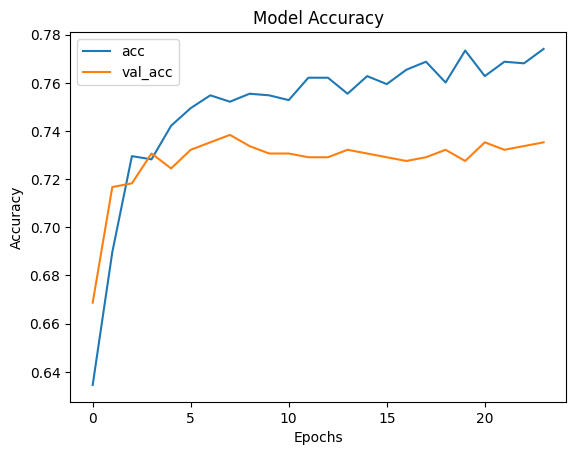

In [18]:
# [정답] (코드 셀) 코드의 빈칸을 채우고 실행하세요
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(['acc', 'val_acc'])
plt.show()

> **해설** : `history.history`는 딕셔너리 형태로, epoch별 loss/accuracy(train), val_loss/
> val_accuracy(valid) 값을 담고 있습니다. 이를 시각화하면 모델이 학습 데이터에 과적합(overfitting)
> 되고 있는지 확인할 수 있습니다.
>
> **학습 포인트** : 학습 Accuracy와 검증 Accuracy의 격차가 크게 벌어진다면 과적합을 의심해볼 수
> 있습니다.
>
> **자주 하는 실수** : `legend()`에 넣는 라벨 순서는 `plt.plot()`을 호출한 순서와 일치해야 합니다.

**[정답] (14-1)** _(실행 불필요)_

`history.history`

**[정답] (14-2)** _(실행 불필요)_

`legend`

---
모든 문항이 완료되었습니다. 수고하셨습니다.

'최종제출 및 종료'를 클릭하셔서 답안을 제출해 주시기 바랍니다.